# Multiple Linear regression 

- We have more than one Input/Independent Features

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
%matplotlib inline
import seaborn as sns


In [2]:
df = pd.read_csv("economic_index.csv")
df.head(6)  # see we have many cols 

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256
5,5,2017,7,2.50,5.6,1254


In [3]:
# we need only intrest_rate and un_employement rate 
# Drop unneccessary cols 

df.drop(columns=["Unnamed: 0", "year", "month"], inplace= True)

# or use this : df.drop(["Unnamed: 0", "year", "month"], axis=1)

In [4]:
df.head()
# now we two Input feature and one output feature 

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256


In [5]:
df.isna().sum()

interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64

___
# Visualization 
___

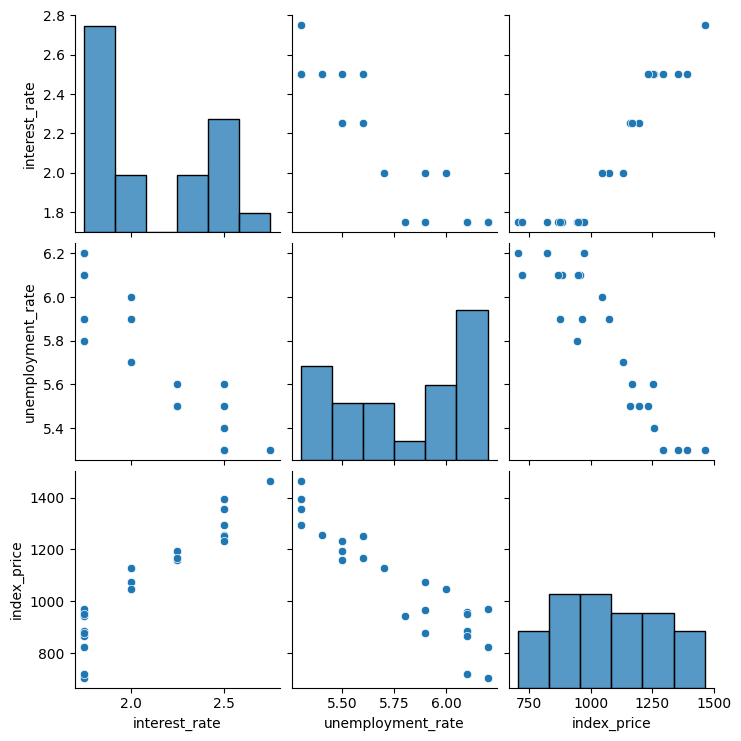

In [6]:
sns.pairplot(df)

In [7]:
df.corr()  
# instrest Rate +ve co-related with index_price
# unemployement -ve co-related with inrest_rate


,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


Text(0, 0.5, 'Unemployement Rate')

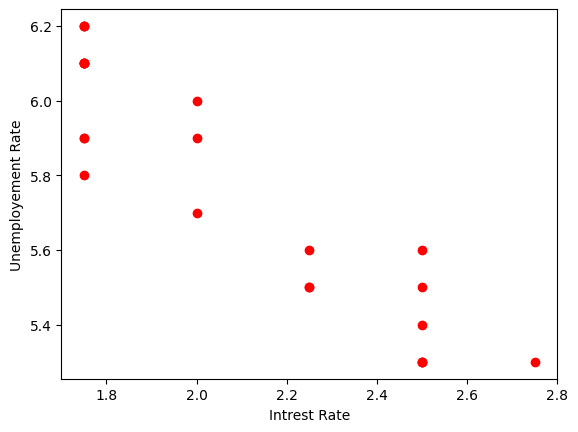

In [8]:
# Visualize datapints more closely

plt.scatter(df["interest_rate"], df["unemployment_rate"], color = "red")
plt.xlabel("Intrest Rate")
plt.ylabel("Unemployement Rate")

# see graph -ve corelated

Text(0, 0.5, 'Index Price')

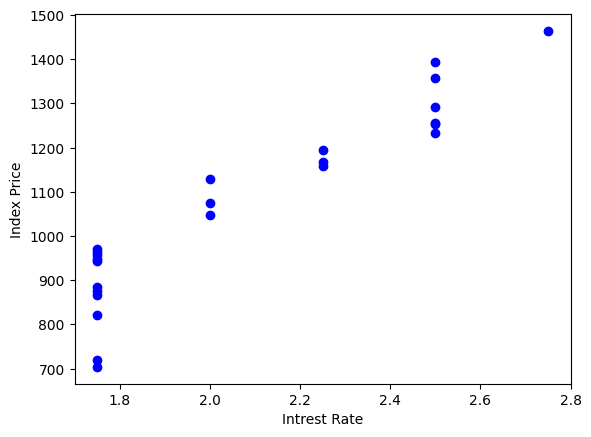

In [9]:
plt.scatter(df["interest_rate"], df["index_price"], color = "Blue")
plt.xlabel("Intrest Rate")
plt.ylabel("Index Price")


___
# Split X and Y 
___


In [10]:
X = df.iloc[:,:-1]
Y = df.iloc[:,-1]

In [11]:
X.head()

,interest_rate,unemployment_rate
0,2.75,5.3
1,2.50,5.3
2,2.50,5.3
3,2.50,5.3
4,2.50,5.4


In [12]:
Y.head()

0    1464
1    1394
2    1357
3    1293
4    1256
Name: index_price, dtype: int64

___
# Train Test Split
___

In [13]:
from sklearn.model_selection import train_test_split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X,Y, test_size=0.25, random_state=42)

In [15]:
X_train

,interest_rate,unemployment_rate
13,1.75,5.9
1,2.50,5.3
21,1.75,6.2
5,2.50,5.6
2,2.50,5.3
12,2.00,6.0
15,1.75,6.1
3,2.50,5.3
4,2.50,5.4
22,1.75,6.2


<Axes: xlabel='interest_rate', ylabel='index_price'>

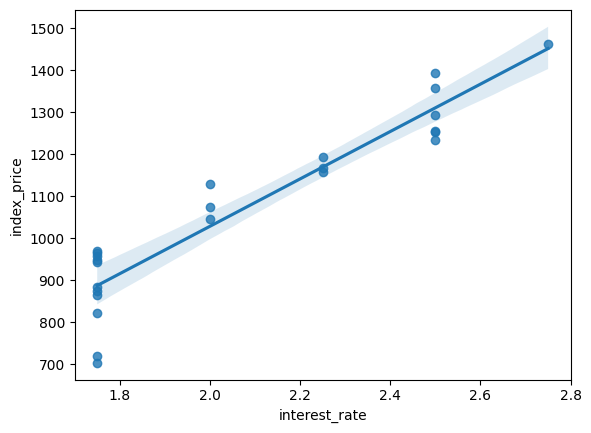

In [16]:
sns.regplot(
    x=df['interest_rate'],
    y=df['index_price']
)

<Axes: xlabel='interest_rate', ylabel='unemployment_rate'>

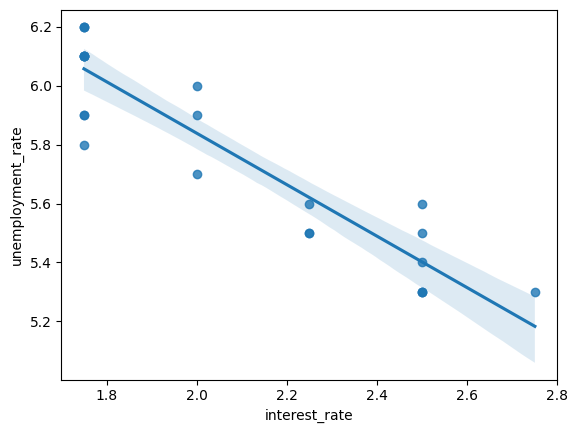

In [17]:
sns.regplot(
    x = df["interest_rate"],
    y = df["unemployment_rate"]
)

___
# Standardization
___

In [18]:
from sklearn.preprocessing import StandardScaler

In [19]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

___
# Linear Regression
___

In [20]:
from sklearn.linear_model import LinearRegression

In [21]:
model = LinearRegression()

In [22]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


___

# Cross Validation

# Cross Validation (`cross_val_score`)

Cross Validation is a technique used to evaluate how well a machine learning model generalizes to unseen data.

Instead of training and testing the model only once, we split the training data into multiple parts and evaluate the model multiple times.

---

## Syntax

```python
from sklearn.model_selection import cross_val_score

validation_score = cross_val_score(
    model,
    X_train,
    y_train,
    scoring="neg_mean_squared_error",
    cv=3
)
```

---

## General Syntax

```python
cross_val_score(
    estimator,
    X,
    y=None,
    scoring=None,
    cv=None
)
```

---

## Parameters

| Parameter | Meaning                    |
| --------- | -------------------------- |
| `model`   | The machine learning model |
| `X_train` | Input features             |
| `y_train` | Target values              |
| `scoring` | Evaluation metric          |
| `cv`      | Number of folds            |

---

## What does `cv=3` mean?

`cv` stands for **Cross Validation folds**.

```python
cv = 3
```

means:

* Split the training data into **3 parts (folds)**.
* Train on **2 parts**.
* Validate on the remaining **1 part**.
* Repeat this process **3 times**.

---

## Simple Dry Run

Suppose we have:

```text
Data:
1 2 3 4 5 6
```

With:

```python
cv = 3
```

the data is split into:

```text
Fold 1: [1 2]
Fold 2: [3 4]
Fold 3: [5 6]
```

### Iteration 1

```text
Train: [3 4 5 6]
Test : [1 2]
```

---

### Iteration 2

```text
Train: [1 2 5 6]
Test : [3 4]
```

---

### Iteration 3

```text
Train: [1 2 3 4]
Test : [5 6]
```

---

The function returns the score for each fold:

```python
validation_score
```

Example:

```python
array([-25.1, -30.2, -28.4])
```

---

## Why are MSE values negative?

Scikit-Learn assumes:

> Higher score = Better model.

Since MSE is an error metric (smaller is better), Scikit-Learn returns:

```python
scoring="neg_mean_squared_error"
```

Example:

```text
Actual MSE:
25
30
28
```

Returned values:

```text
-25
-30
-28
```

To get the real MSE:

```python
mse = -validation_score
```

---

## Finding Average Performance

```python
import numpy as np

avg_score = np.mean(validation_score)
```

For MSE:

```python
avg_mse = -np.mean(validation_score)
```

---

## Common Values of `cv`

| Value   | Meaning                  |
| ------- | ------------------------ |
| `cv=3`  | 3-fold cross validation  |
| `cv=5`  | 5-fold cross validation  |
| `cv=10` | 10-fold cross validation |

Usually:

```python
cv = 5
```

or

```python
cv = 10
```

are most commonly used.

---

## Example

```python
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    model,
    X_train,
    y_train,
    scoring="r2",
    cv=5
)

print(scores)
print(scores.mean())
```

---

## One-Line Definition

> Cross Validation repeatedly splits the training data into training and validation folds to estimate how well the model will perform on unseen data.


___
___

In [23]:
from sklearn.model_selection import cross_val_score

In [24]:
validation_score = cross_val_score(model, X_train, y_train, scoring="neg_mean_squared_error", cv=3)  
# cv = 3 means divide train data into 3 folds 
# train on 2 folds and test on 1 fold 
# repeat this 3 times 

# scoring metrics is : neg mean sq, so after every iteration we would get a mse error ,,, totlal mse values 3
# find averge of as 

In [25]:
validation_score

array([-4921.61331265, -7686.87497294, -5135.9962549 ])

In [26]:
np.mean(validation_score)

np.float64(-5914.828180162386)

___
# Prediction
___

In [27]:
y_pred = model.predict(X_test)

In [28]:
# See first 5 predictions vs actual scores
print("Predicted  :", y_pred[:5].round(2))
print("Actual     :", y_test.values[:5])

Predicted  : [1204.23  821.65 1406.51  857.71  994.91]
Actual     : [1159  971 1464  884 1075]


___
# PERFORMANCE METRICS
___

In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("MSE : ", mse)
print("MAE : ", mae)
print("RMSE : ", rmse)

MSE :  5793.762887712569
MAE :  59.935781523235484
RMSE :  76.11677139574805


In [30]:
from sklearn.metrics import r2_score

In [31]:
r2_score = r2_score(y_test, y_pred)
print((r2_score))

0.8278978091457145


In [32]:
X_test.shape

(6, 2)

In [33]:
n = X_test.shape[0]  # number of Data points ; that is 6
p = X_test.shape[1]  # number of Independent Features that is 2

adjusted_r2 =  1 - (1 - r2_score) * ( n - 1) / ( n - p - 1)
adjusted_r2


0.7131630152428576

___
# ASsumption
___

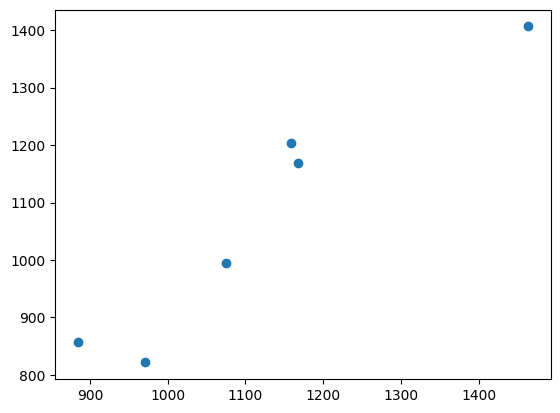

In [34]:
plt.scatter(y_test, y_pred)

# if there is linear relation between actual and predicted value means Model performed Well

In [35]:
residuals = y_test - y_pred
print( residuals) 
# plot this residuals

8     -45.227704
16    149.349481
0      57.486996
18     26.291104
11     80.090077
9      -1.169327
Name: index_price, dtype: float64


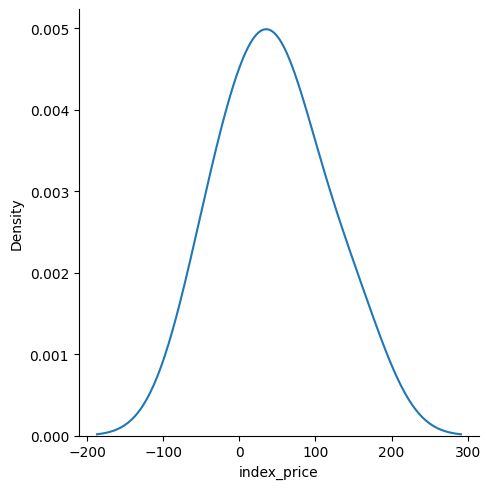

In [ ]:
sns.displot(residuals, kind = "kde")
# if we get bell Curve of Residals means Model has performed well 

Text(0, 0.5, 'residuals')

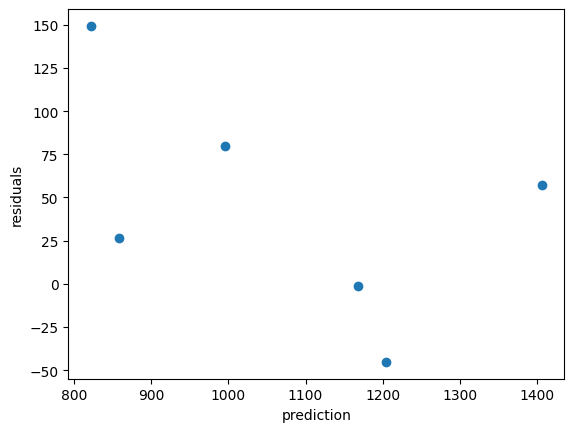

In [ ]:
# Scatter Plot with predictions and residuals 
plt.scatter(y_pred, residuals)
plt.xlabel("prediction")
plt.ylabel("residuals")

# See the Points are ereryWhere on the graph ( means uniformly distributed ) so model performed well 
